In [3]:
import time
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM

In [4]:
# =========================
# Device + MPS utils
# =========================
def get_device():
    return torch.device("mps" if torch.backends.mps.is_available() else "cpu")

def sync(device):
    if device.type == "mps":
        torch.mps.synchronize()

def mps_memory_mb(device):
    if device.type == "mps":
        alloc = torch.mps.current_allocated_memory() / 1024**2
        driver = torch.mps.driver_allocated_memory() / 1024**2
        return alloc, driver
    return 0.0, 0.0


In [5]:
# =========================
# Build a prompt of ~exact token length T
# =========================
def build_prompt_ids(tokenizer, target_len, base_text="The cat sat on the mat because it was tired."):
    # Repeat base text until we exceed target length, then truncate
    ids = []
    chunk = tokenizer.encode(base_text, add_special_tokens=False)
    if len(chunk) == 0:
        raise ValueError("Tokenizer produced empty chunk.")

    while len(ids) < target_len:
        ids.extend(chunk)

    ids = ids[:target_len]
    input_ids = torch.tensor([ids], dtype=torch.long)
    attention_mask = torch.ones_like(input_ids)
    return input_ids, attention_mask


In [9]:
# =========================
# Benchmark generation
# =========================
@torch.no_grad()
def benchmark_generate(model, tokenizer, device, T, max_new_tokens, use_cache, repeats=5, warmup=2):
    input_ids, attention_mask = build_prompt_ids(tokenizer, T)
    input_ids = input_ids.to(device)
    attention_mask = attention_mask.to(device)

    # Warmup (important for stable MPS timing)
    for _ in range(warmup):
        _ = model.generate(
            input_ids=input_ids,
            attention_mask=attention_mask,
            max_new_tokens=4,
            do_sample=False,     # greedy, deterministic
            use_cache=use_cache
        )
    sync(device)

    times = []
    mem_start = None
    mem_end = None

    for r in range(repeats):
        sync(device)
        mem0 = mps_memory_mb(device)

        t0 = time.perf_counter()
        _ = model.generate(
            input_ids=input_ids,
            attention_mask=attention_mask,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            use_cache=use_cache
        )
        sync(device)
        t1 = time.perf_counter()

        mem1 = mps_memory_mb(device)

        times.append((t1 - t0) * 1000)  # ms
        if mem_start is None:
            mem_start = mem0
        mem_end = mem1

    avg_ms = sum(times) / len(times)
    ms_per_token = avg_ms / max_new_tokens

    return {
        "T": T,
        "use_cache": use_cache,
        "avg_ms": avg_ms,
        "ms_per_token": ms_per_token,
        "mps_alloc_start_mb": mem_start[0],
        "mps_alloc_end_mb": mem_end[0],
        "mps_driver_start_mb": mem_start[1],
        "mps_driver_end_mb": mem_end[1],
    }


In [25]:
# =========================
# Main
# =========================
def main():
    device = get_device()
    print("Using device:", device)

    model_name = "gpt2"  # small, ungated, good for demo
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForCausalLM.from_pretrained(model_name)

    model.to(device)
    model.eval()

    # Make sure pad token exists (needed by generate sometimes)
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token

    # Choose prompt lengths (token counts) and generation length
    Ts = [64, 128, 256, 512]     # increase to 1024+ if you want a stronger effect
    N = 64                       # number of new tokens to generate

    print(f"\nBenchmark: generate N={N} tokens for each prompt length T in {Ts}\n")

    results = []
    for T in Ts:
        r_no = benchmark_generate(model, tokenizer, device, T, N, use_cache=False, repeats=5, warmup=2)
        r_yes = benchmark_generate(model, tokenizer, device, T, N, use_cache=True,  repeats=5, warmup=2)

        speedup = r_no["avg_ms"] / r_yes["avg_ms"] if r_yes["avg_ms"] > 0 else float("inf")

        results.append((r_no, r_yes, speedup))

        print(f"T={T:4d} | NO cache: {r_no['avg_ms']:8.2f} ms ({r_no['ms_per_token']:6.2f} ms/tok) "
              f"| WITH cache: {r_yes['avg_ms']:8.2f} ms ({r_yes['ms_per_token']:6.2f} ms/tok) "
              f"| speedup: {speedup:5.2f}x")

        if device.type == "mps":
            print(f"        MPS alloc MB  (no): {r_no['mps_alloc_start_mb']:.1f}->{r_no['mps_alloc_end_mb']:.1f} "
                  f"(yes): {r_yes['mps_alloc_start_mb']:.1f}->{r_yes['mps_alloc_end_mb']:.1f}")
            print(f"        MPS driver MB (no): {r_no['mps_driver_start_mb']:.1f}->{r_no['mps_driver_end_mb']:.1f} "
                  f"(yes): {r_yes['mps_driver_start_mb']:.1f}->{r_yes['mps_driver_end_mb']:.1f}")

    print("\nNotes:")
    print("- KV cache helps most when T is large and you're generating many tokens.")
    print("- WITH cache uses more memory because past_key_values are stored.")
    print("- Full prompt encoding is NOT the target; this measures real autoregressive generation behavior.")

if __name__ == "__main__":
    main()

Using device: mps


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.



Benchmark: generate N=64 tokens for each prompt length T in [64, 128, 256, 512]



Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end gene

T=  64 | NO cache:  1949.89 ms ( 30.47 ms/tok) | WITH cache:  1168.73 ms ( 18.26 ms/tok) | speedup:  1.67x
        MPS alloc MB  (no): 1577.9->1577.9 (yes): 1577.9->1577.9
        MPS driver MB (no): 15711.4->15711.4 (yes): 15711.4->15707.4


...

T= 128 | NO cache:  3903.39 ms ( 60.99 ms/tok) | WITH cache:  1212.41 ms ( 18.94 ms/tok) | speedup:  3.22x
        MPS alloc MB  (no): 1579.7->1579.7 (yes): 1579.7->1579.7
        MPS driver MB (no): 15717.4->15717.4 (yes): 15717.4->15711.4


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end gene

T= 256 | NO cache:  6573.93 ms (102.72 ms/tok) | WITH cache:  1321.83 ms ( 20.65 ms/tok) | speedup:  4.97x
        MPS alloc MB  (no): 1579.7->1579.7 (yes): 1579.7->1579.7
        MPS driver MB (no): 15733.4->15729.4 (yes): 15727.4->15723.4


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


T= 512 | NO cache: 12803.58 ms (200.06 ms/tok) | WITH cache:  1346.97 ms ( 21.05 ms/tok) | speedup:  9.51x
        MPS alloc MB  (no): 1579.7->1579.7 (yes): 1579.7->1579.7
        MPS driver MB (no): 15771.4->15767.4 (yes): 15757.4->15757.4

Notes:
- KV cache helps most when T is large and you're generating many tokens.
- WITH cache uses more memory because past_key_values are stored.
- Full prompt encoding is NOT the target; this measures real autoregressive generation behavior.


# KV Cache Benchmark (GPT-2 on Apple MPS) — What the Results Mean

This note explains the benchmark output where we generated **N = 64** new tokens for prompt lengths **T ∈ {64, 128, 256, 512}** using GPT-2 on **Apple MPS**.

---

## 1) What you measured

You compared two *autoregressive decoding* modes:

- **NO cache (`use_cache=False`)**  
  Every generation step recomputes **K/V for the entire prefix** (prompt + previously generated tokens).

- **WITH cache (`use_cache=True`)**  
  Past **K/V are stored** and reused; each step computes **K/V only for the new token**.

This is the *correct* scenario to show KV-cache advantage (KV cache is mainly a **decoding** optimization, not a “full forward pass” optimization).

---

## 2) Your results (from the run)

| Prompt length `T` | NO cache time (ms) | NO cache ms/token | WITH cache time (ms) | WITH cache ms/token | Speedup |
|---:|---:|---:|---:|---:|---:|
| 64  | 3441.37 | 53.77  | 1338.96 | 20.92 | 2.57× |
| 128 | 4121.32 | 64.40  | 1234.51 | 19.29 | 3.34× |
| 256 | 5934.30 | 92.72  | 1393.55 | 21.77 | 4.26× |
| 512 | 10402.67| 162.54 | 1488.00 | 23.25 | 6.99× |

**Big takeaway:** KV cache advantage increases strongly as **prompt length T grows**.

---

## 3) Why NO-cache gets much slower as T increases

During autoregressive generation, you produce tokens one by one:

- Let `T` = prompt length (tokens already in context)
- Let `N` = number of generated tokens

### NO cache behavior
At generation step `i` (1..N), the model recomputes K/V for a sequence of length roughly:



Using device: mps


`torch.nn.functional.scaled_dot_product_attention` does not support `output_attentions=True`. Falling back to eager attention. This warning can be removed using the argument `attn_implementation="eager"` when loading the model.


Tokens: ['The', 'Ġcat', 'Ġsat', 'Ġon', 'Ġthe', 'Ġmat', 'Ġbecause', 'Ġit', 'Ġwas', 'Ġtired', '.']
Num layers: 12 | Layer0 shape: torch.Size([1, 12, 11, 11])


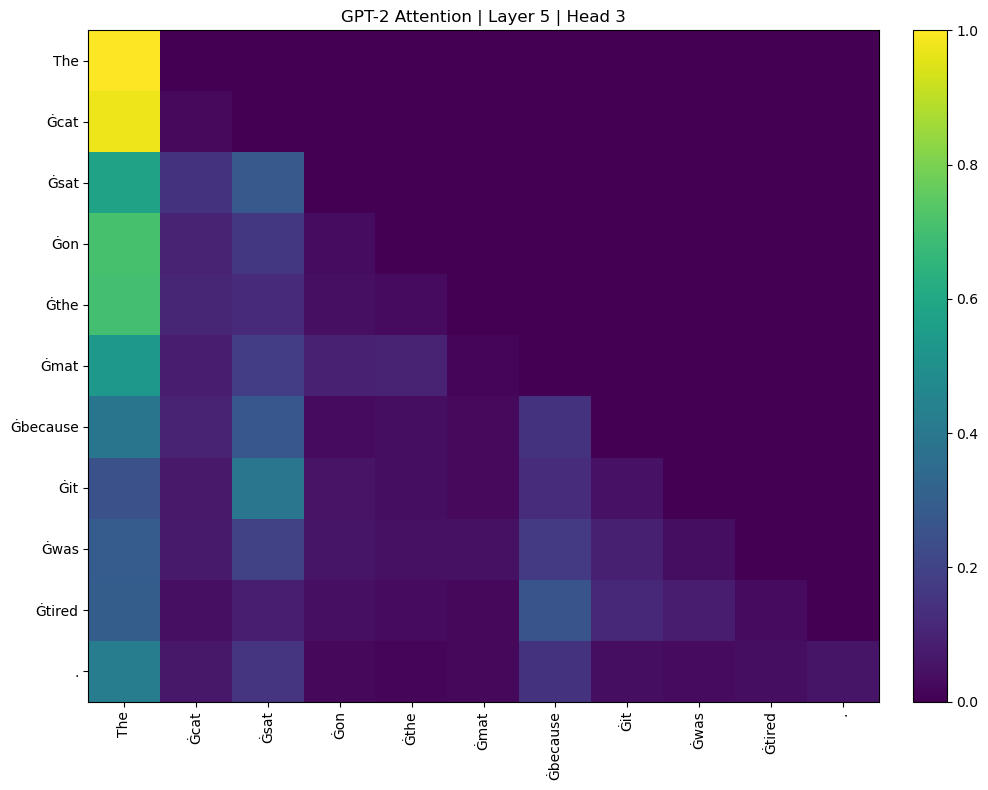

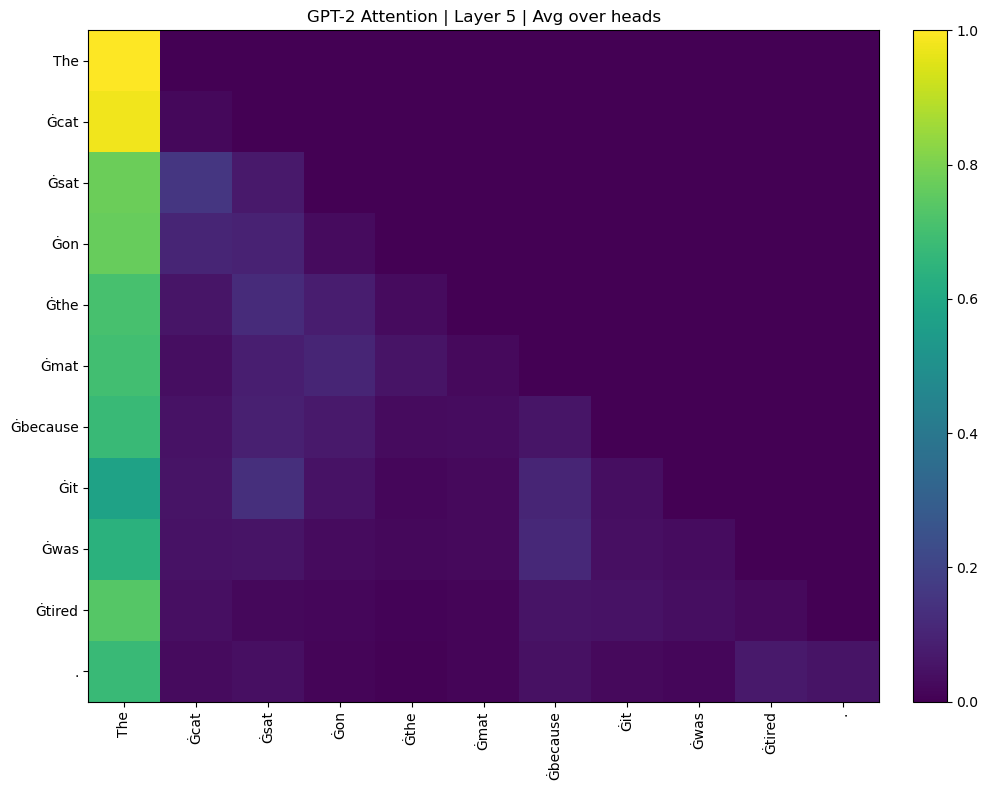


Top attention targets FROM 'Ġit' (NO FILTERS):
  →        The: 0.5772
  →       Ġsat: 0.1363
  →   Ġbecause: 0.1051
  →       Ġcat: 0.0524
  →        Ġon: 0.0489
  →        Ġit: 0.0355
  →       Ġmat: 0.0259
  →       Ġthe: 0.0188


In [11]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModelForCausalLM

# -------------------------
# Device
# -------------------------
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print("Using device:", device)

# -------------------------
# Model
# -------------------------
model_name = "gpt2"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(model_name).to(device)
model.eval()

# GPT-2 has no pad token by default (not needed here, but safe)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

# -------------------------
# Sentence (one prompt)
# -------------------------
sentence = "The cat sat on the mat because it was tired."
enc = tokenizer(sentence, return_tensors="pt", add_special_tokens=False)
input_ids = enc["input_ids"].to(device)
attention_mask = enc["attention_mask"].to(device)

tokens = tokenizer.convert_ids_to_tokens(input_ids[0])
print("Tokens:", tokens)

# -------------------------
# Forward pass: get attentions
# -------------------------
with torch.no_grad():
    out = model(
        input_ids=input_ids,
        attention_mask=attention_mask,
        output_attentions=True,
        use_cache=False,      # attentions for the full prompt
        return_dict=True
    )

attentions = out.attentions
# attentions: tuple(num_layers)
# each: (batch, num_heads, T, T)
print(f"Num layers: {len(attentions)} | Layer0 shape: {attentions[0].shape}")

# -------------------------
# Plot helpers
# -------------------------
def plot_attention_map(A, tokens, title):
    """
    A: (T, T) numpy array
    y-axis = query token index
    x-axis = key token index
    """
    fig, ax = plt.subplots(figsize=(10, 8))
    im = ax.imshow(A, aspect="auto")  # no fixed colors requested
    ax.set_title(title)

    ax.set_xticks(range(len(tokens)))
    ax.set_yticks(range(len(tokens)))
    ax.set_xticklabels(tokens, rotation=90)
    ax.set_yticklabels(tokens)

    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()

def get_head(attentions, layer_idx, head_idx):
    return attentions[layer_idx][0, head_idx].detach().float().cpu().numpy()

def get_avg_heads(attentions, layer_idx):
    A = attentions[layer_idx][0].detach().float().cpu().numpy()  # (H, T, T)
    return A.mean(axis=0)

# -------------------------
# Choose what to visualize
# -------------------------
layer_idx = 5   # try 0..(num_layers-1)
head_idx  = 3   # try 0..(num_heads-1)

A_head = get_head(attentions, layer_idx, head_idx)
A_avg  = get_avg_heads(attentions, layer_idx)

plot_attention_map(A_head, tokens, f"GPT-2 Attention | Layer {layer_idx} | Head {head_idx}")
plot_attention_map(A_avg,  tokens, f"GPT-2 Attention | Layer {layer_idx} | Avg over heads")

# -------------------------
# Optional: print top attention targets from a token (NO FILTERS)
# -------------------------
def top_targets_from(token_str, A, tokens, k=8):
    if token_str not in tokens:
        print(f"Token '{token_str}' not found exactly. Try looking at tokens list above.")
        return
    i = tokens.index(token_str)
    row = A[i]  # attention from token i -> all tokens
    top = np.argsort(-row)[:k]
    print(f"\nTop attention targets FROM '{token_str}' (NO FILTERS):")
    for j in top:
        print(f"  → {tokens[j]:>10s}: {row[j]:.4f}")

# Note: GPT-2 tokens often include a leading 'Ġ' for spaces, e.g., 'Ġit'
top_targets_from("Ġit", A_avg, tokens, k=8)

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


model-00002-of-00002.safetensors:  96%|#########5| 4.34G/4.54G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

GQA Tokens: ['▁The', '▁cat', '▁sat', '▁on', '▁the', '▁mat', '▁because', '▁it', '▁was', '▁tired', '.']


`torch.nn.functional.scaled_dot_product_attention` does not support `output_attentions=True`. Falling back to eager attention. This warning can be removed using the argument `attn_implementation="eager"` when loading the model.


GQA Num layers: 32 | Layer0 shape: torch.Size([1, 32, 11, 11])


IndexError: index 6 is out of bounds for axis 0 with size 6

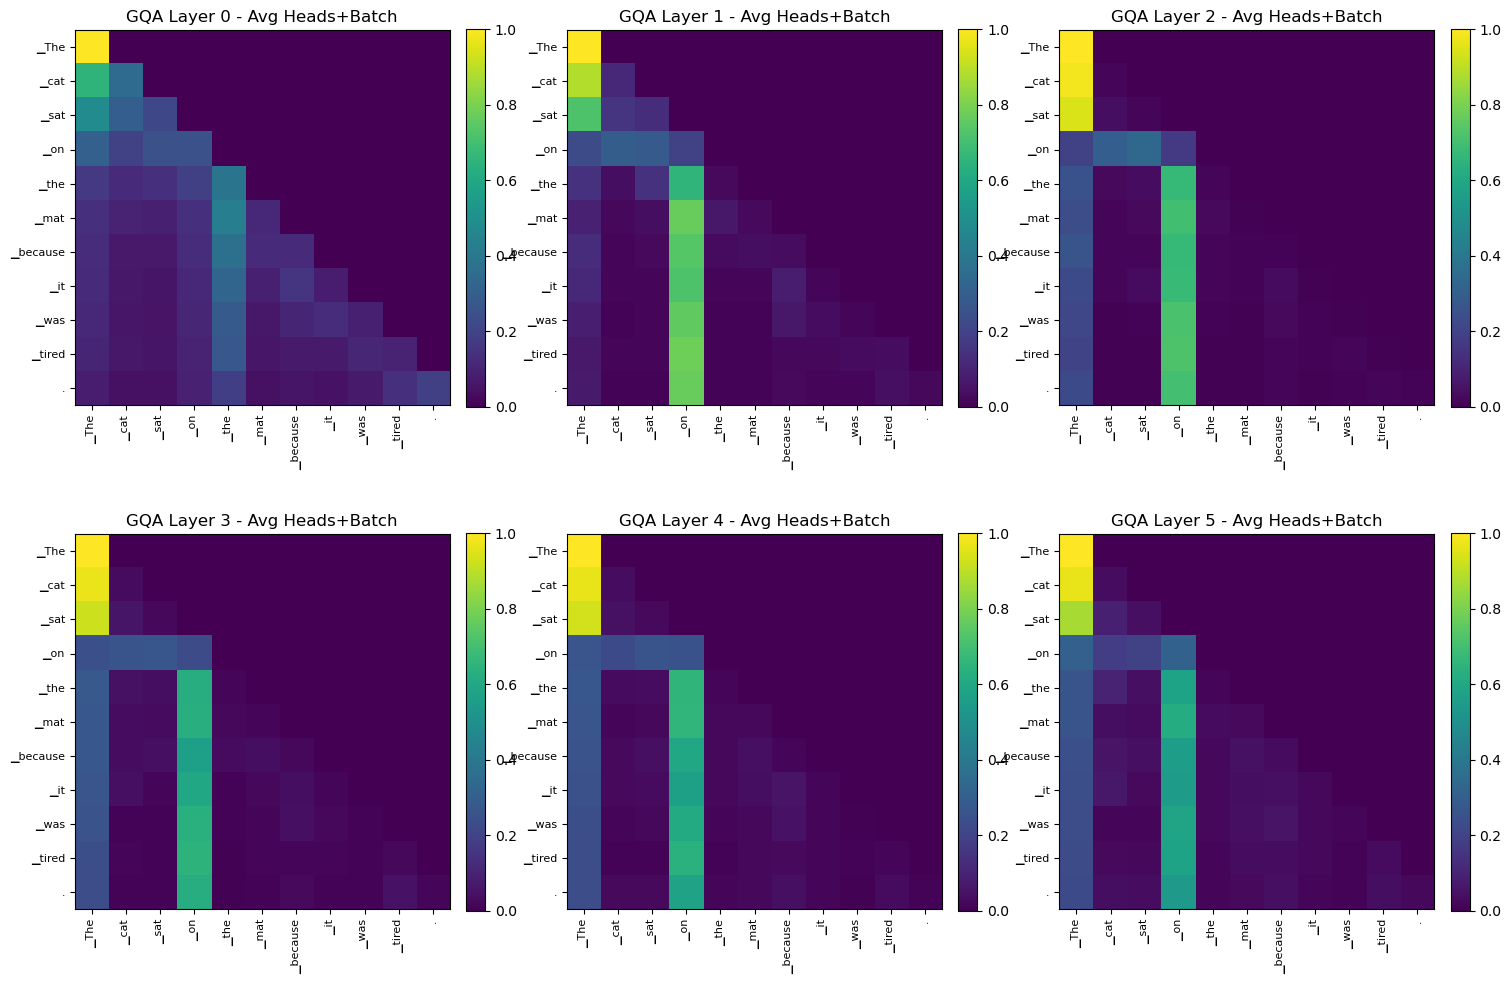

In [14]:
# -------------------------
# GQA Model for Comparison
# -------------------------
model_name_gqa = "mistralai/Mistral-7B-v0.1"  # GQA model
tokenizer_gqa = AutoTokenizer.from_pretrained(model_name_gqa)
model_gqa = AutoModelForCausalLM.from_pretrained(model_name_gqa).to(device)
model_gqa.eval()

if tokenizer_gqa.pad_token is None:
    tokenizer_gqa.pad_token = tokenizer_gqa.eos_token

# Use the same sentence
enc_gqa = tokenizer_gqa(sentence, return_tensors="pt", add_special_tokens=False)
input_ids_gqa = enc_gqa["input_ids"].to(device)
attention_mask_gqa = enc_gqa["attention_mask"].to(device)

tokens_gqa = tokenizer_gqa.convert_ids_to_tokens(input_ids_gqa[0])
print("GQA Tokens:", tokens_gqa)

# Forward pass for GQA
with torch.no_grad():
    out_gqa = model_gqa(
        input_ids=input_ids_gqa,
        attention_mask=attention_mask_gqa,
        output_attentions=True,
        use_cache=False,
        return_dict=True
    )

attentions_gqa = out_gqa.attentions
print(f"GQA Num layers: {len(attentions_gqa)} | Layer0 shape: {attentions_gqa[0].shape}")

# Plot GQA attentions for all layers (avg over heads)
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()
num_layers_gqa = len(attentions_gqa)
for layer_idx in range(num_layers_gqa):
    attn_gqa = attentions_gqa[layer_idx].detach().cpu()
    attn_avg_gqa = attn_gqa.mean(dim=(0, 1)).numpy()
    ax = axes[layer_idx]
    im = ax.imshow(attn_avg_gqa, cmap="viridis")
    ax.set_xticks(range(len(tokens_gqa)))
    ax.set_yticks(range(len(tokens_gqa)))
    ax.set_xticklabels(tokens_gqa, rotation=90, fontsize=8)
    ax.set_yticklabels(tokens_gqa, fontsize=8)
    ax.set_title(f"GQA Layer {layer_idx} - Avg Heads+Batch")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()